# Conic Quadpole — point extraction

The CCGA conic **quadpole** `Q = p1 ^ p2 ^ p3 ^ p4` (grade 4). A quadpole is
literally a **wedge of two dipoles**, for each of the 3 pairings:
$$Q = \mathbf{pp}_{12}\wedge\mathbf{pp}_{34} = \mathbf{pp}_{13}\wedge\mathbf{pp}_{24}
     = \mathbf{pp}_{14}\wedge\mathbf{pp}_{23}\quad(\text{up to sign}).$$
So extraction decomposes into **two dipole extractions** — Ferrari's quartic
method: a **resolvent cubic** picks the pairing, then two quadratics (`±√`).

Pipeline (from `Q` alone):
1. pencil of conics through the 4 points = kernel of `s ↦ s⌟Q`,
2. its 3 degenerate members (line-pairs) = **resolvent cubic** `det = 0`,
3. each line carries 2 points → `point(λ)∧Q = 0` is a quadratic → `±√`.

Select the **CCGA (.venv)** kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ccga.algebra import alg, e1, e2, eo, einf, einf1, einf2, einf3, eo1, eo2, eo3
from ccga.point import point
from ccga.classify import ipns_to_coeffs

def sq(mv):
    s = mv * mv
    try: return float(s.e)
    except: return 0.0
def grades(mv): return sorted({bin(k).count('1') for k in mv.keys()})

# four real points in general position
P = [(0.3, 1.7), (2.1, -0.4), (-1.2, 0.9), (1.5, 2.3)]
p = [point(*c) for c in P]
Q = p[0] ^ p[1] ^ p[2] ^ p[3]
print('grades(Q):', grades(Q), '  Q^2 =', round(sq(Q), 4))

grades(Q): [4]   Q^2 = -82.8737


## 1. A quadpole is a wedge of two dipoles

`Q = pp_ij ^ pp_kl` for all three pairings (sign flips with reordering).

In [2]:
for (a, b), (c, d) in [((0,1),(2,3)), ((0,2),(1,3)), ((0,3),(1,2))]:
    D = Q - ((p[a]^p[b]) ^ (p[c]^p[d]))
    Dn = Q + ((p[a]^p[b]) ^ (p[c]^p[d]))
    err = min(max((abs(v) for v in D.values()), default=0),
              max((abs(v) for v in Dn.values()), default=0))   # match up to sign
    print(f'Q = ± pp{a+1}{b+1} ^ pp{c+1}{d+1}   err = {err:.1e}')

Q = ± pp12 ^ pp34   err = 3.6e-15
Q = ± pp13 ^ pp24   err = 4.4e-15
Q = ± pp14 ^ pp23   err = 5.8e-15


## 2. Contraction identity and the line-peeling handle

`v ⌟ Q` is a sum of four tripoles. Contracting with a **line through two points**
cancels two terms and leaves `(vector) ∧ pp` — a blade carrying that pair's dipole.

In [3]:
v = 0.7*e1 - 1.3*e2 + 0.5*eo + 2.0*einf
lhs = v | Q
rhs = ( float((v|p[0]).e)*(p[1]^p[2]^p[3]) - float((v|p[1]).e)*(p[0]^p[2]^p[3])
      + float((v|p[2]).e)*(p[0]^p[1]^p[3]) - float((v|p[3]).e)*(p[0]^p[1]^p[2]) )
print('contraction identity  max|lhs-rhs| =', max(abs(x) for x in (lhs-rhs).values()))

def line_through(A, B):
    ax, ay = A; bx, by = B
    nx, ny = (by-ay), -(bx-ax); d = nx*ax + ny*ay
    return nx*e1 + ny*e2 + d*einf                 # IPNS line: v·p = nx x + ny y - d

ell = line_through(P[0], P[1])                    # through p1, p2
G = ell | Q
D = float((ell|p[2]).e)*p[3] - float((ell|p[3]).e)*p[2]
print('grades(ell12 ⌟ Q):', grades(G),
      '   ell12⌟Q == (…)^pp12 :', max(abs(x) for x in (G - (D^(p[0]^p[1]))).values()))

contraction identity  max|lhs-rhs| = 1.021405182655144e-14
grades(ell12 ⌟ Q): [3]    ell12⌟Q == (…)^pp12 : 1.4210854715202004e-14


## 3. Autonomous extraction from `Q` alone

**(a) pencil** — the conics through the 4 points are the kernel of `s ↦ s⌟Q`
(since `s⌟Q = Σ ±(s·p_i)·tripole_i`, vanishing iff `s·p_i = 0 ∀i`). Mapping to
conic coefficients `(A,B,C,D,E,F)` gives a 2-D pencil.

In [4]:
basis = [e1, e2, eo1, einf1, eo2, einf2, eo3, einf3]

def pencil(Q):
    vec3 = lambda mv: {k: float(v) for k, v in mv.items() if bin(k).count('1') == 3}
    contr = [vec3(b | Q) for b in basis]
    keys = sorted(set().union(*[set(c) for c in contr]))
    M = np.array([[c.get(k, 0.0) for k in keys] for c in contr]).T
    _, S, Vt = np.linalg.svd(M)
    ker = np.array([Vt[i] for i in range(8) if (i >= len(S) or S[i] < 1e-9)])
    conic = lambda kv: np.array(ipns_to_coeffs(sum(kv[i]*basis[i] for i in range(8))), float)
    Cm = np.array([conic(kv) for kv in ker])
    _, _, Vtc = np.linalg.svd(Cm)
    return Vtc[0], Vtc[1]                          # two conic-coeff generators

G1, G2 = pencil(Q)
print('pencil generators (A,B,C,D,E,F):')
print('  G1 =', np.round(G1, 3)); print('  G2 =', np.round(G2, 3))

pencil generators (A,B,C,D,E,F):
  G1 = [-0.133 -0.066  0.277 -0.087 -0.441  0.836]
  G2 = [ 0.006 -0.574  0.258  0.145  0.717  0.264]


**(b) resolvent cubic** — degenerate members of the pencil (`det = 0`) are the
three line-pairs = the three pairings.

In [5]:
def conic_mat(c):
    A, B, C, D, E, F = c
    return np.array([[A, C/2, D/2], [C/2, B, E/2], [D/2, E/2, F]])

ts = np.linspace(-50, 50, 9)
cubic = np.polyfit(ts, [np.linalg.det(conic_mat(G1 + t*G2)) for t in ts], 3)
roots = [r.real for r in np.roots(cubic) if abs(r.imag) < 1e-6]
print('resolvent cubic roots:', [round(r, 4) for r in roots])
for r in roots:
    ev = np.linalg.eigvalsh(conic_mat(G1 + r*G2))
    print(f'  t={r:+.3f}  eigvals={np.round(ev,3)}  (signature -,0,+ = two real lines)')

resolvent cubic roots: [np.float64(-1.3666), np.float64(-0.5067), np.float64(-0.2118)]
  t=-1.367  eigvals=[-0.268  0.     1.32 ]  (signature -,0,+ = two real lines)
  t=-0.507  eigvals=[-0.15   0.     0.942]  (signature -,0,+ = two real lines)
  t=-0.212  eigvals=[-0.193  0.     0.895]  (signature -,0,+ = two real lines)


**(c) two dipoles** — each degenerate conic splits into two lines; each line
carries two points, found by `point(λ)∧Q = 0`, a quadratic in `λ` (`±√`).

In [6]:
def lines_of(coef):
    Mc = conic_mat(coef); w, V = np.linalg.eigh(Mc); i = np.argsort(w)
    u = np.sqrt(w[i[2]]) * V[:, i[2]]; v = np.sqrt(-w[i[0]]) * V[:, i[0]]
    return (u + v), (u - v)                        # homogeneous lines [a,b,c]

KEYS = sorted(dict((p[0] ^ Q).items()).keys())
def pQ(x, y):
    d = dict((point(x, y) ^ Q).items())
    return np.array([float(d.get(k, 0.0)) for k in KEYS])

def dipole_on_line(L):
    a, b, c = L; n2 = a*a + b*b
    base = np.array([-a*c, -b*c]) / n2; dirv = np.array([-b, a]) / np.sqrt(n2)
    L0, L1, L2 = pQ(*(base-dirv)), pQ(*base), pQ(*(base+dirv))   # quadratic in λ
    A = 0.5*(L0 + L2) - L1; B = 0.5*(L2 - L0)
    j = int(np.argmax(np.abs(A))); disc = B[j]**2 - 4*A[j]*L1[j]
    return [tuple(np.round(base + r*dirv, 3))
            for r in ((-B[j]+disc**0.5)/(2*A[j]), (-B[j]-disc**0.5)/(2*A[j]))]

print('each resolvent root -> a pairing -> two ±√ dipoles:')
for r in roots:
    La, Lb = lines_of(G1 + r*G2)
    print(f'  t={r:+.3f}:  {dipole_on_line(La)}  |  {dipole_on_line(Lb)}')
print('original:', P)

def extract_quadpole(Q):
    G1, G2 = pencil(Q)
    cub = np.polyfit(ts, [np.linalg.det(conic_mat(G1 + t*G2)) for t in ts], 3)
    r = [x.real for x in np.roots(cub) if abs(x.imag) < 1e-6][0]   # any pairing works
    La, Lb = lines_of(G1 + r*G2)
    return dipole_on_line(La) + dipole_on_line(Lb)

print('\nextract_quadpole(Q) ->', sorted(extract_quadpole(Q)))

each resolvent root -> a pairing -> two ±√ dipoles:
  t=-1.367:  [(np.float64(1.5), np.float64(2.3)), (np.float64(0.3), np.float64(1.7))]  |  [(np.float64(2.1), np.float64(-0.4)), (np.float64(-1.2), np.float64(0.9))]
  t=-0.507:  [(np.float64(0.3), np.float64(1.7)), (np.float64(2.1), np.float64(-0.4))]  |  [(np.float64(-1.2), np.float64(0.9)), (np.float64(1.5), np.float64(2.3))]
  t=-0.212:  [(np.float64(0.3), np.float64(1.7)), (np.float64(-1.2), np.float64(0.9))]  |  [(np.float64(2.1), np.float64(-0.4)), (np.float64(1.5), np.float64(2.3))]
original: [(0.3, 1.7), (2.1, -0.4), (-1.2, 0.9), (1.5, 2.3)]

extract_quadpole(Q) -> [(np.float64(-1.2), np.float64(0.9)), (np.float64(0.3), np.float64(1.7)), (np.float64(1.5), np.float64(2.3)), (np.float64(2.1), np.float64(-0.4))]


## 4. Round-trip + visualization

rebuilt Q / Q  (constant up to scale): -1.0 .. -1.0


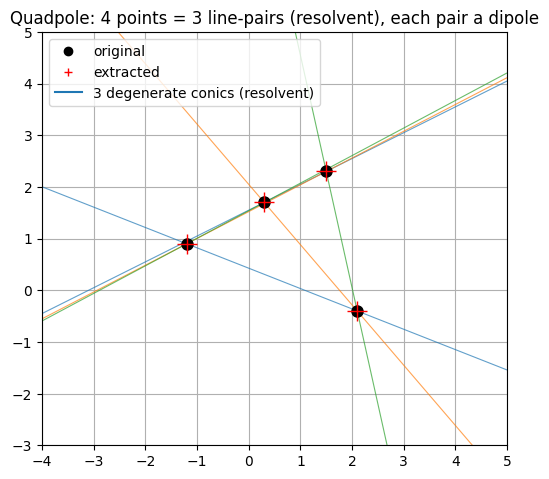

In [7]:
got = extract_quadpole(Q)
Qr = point(*got[0]) ^ point(*got[1]) ^ point(*got[2]) ^ point(*got[3])
dQ, dQr = dict(Q.items()), dict(Qr.items())
ratios = [dQr[k]/dQ[k] for k in dQ if abs(dQ[k]) > 1e-9]
print('rebuilt Q / Q  (constant up to scale):', round(min(ratios), 3), '..', round(max(ratios), 3))

%matplotlib inline
fig, ax = plt.subplots(figsize=(6, 6))
xs = np.linspace(-4, 5, 400); ys = np.linspace(-3, 5, 400); X, Y = np.meshgrid(xs, ys)
for r, col in zip(roots, ['C0', 'C1', 'C2']):
    A, B, Cc, D, E, F = G1 + r*G2
    ax.contour(X, Y, A*X**2 + B*Y**2 + Cc*X*Y + D*X + E*Y + F, [0],
               colors=col, linewidths=0.8, alpha=0.7)
for (x, y) in P: ax.plot(x, y, 'ko', ms=8)
for (x, y) in got: ax.plot(x, y, 'r+', ms=14)
ax.plot([], [], 'ko', label='original'); ax.plot([], [], 'r+', label='extracted')
ax.plot([], [], 'C0-', label='3 degenerate conics (resolvent)')
ax.set_aspect('equal'); ax.grid(True); ax.legend(loc='upper left')
ax.set_title('Quadpole: 4 points = 3 line-pairs (resolvent), each pair a dipole')
plt.show()